# RNA-seq differential expression with DESeq2 (airway dataset) - Colab R version

**Before running:** this notebook needs the **R** runtime. If the menu shows Python, go to *Runtime > Change runtime type* and choose **R**.
Run the cells from top to bottom (Shift+Enter). The first cell takes 15 to 30 minutes the first time, because Bioconductor packages are compiled.
Keep this browser tab open while it installs. If the session disconnects, run the install cell again.

## 1. Install packages

In [1]:
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install(c("DESeq2", "airway", "org.Hs.eg.db", "AnnotationDbi"), ask = FALSE, update = FALSE)
install.packages(c("ggplot2", "dplyr", "pheatmap"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'DESeq2', 'airway', 'org.Hs.eg.db',
  'AnnotationDbi'

also installing the dependencies ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘XVector’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘png’, ‘Biostrings’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’, ‘RSQLite’, ‘KEGGREST’


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 2. Load data and fit the model

In [2]:
suppressPackageStartupMessages({
  library(DESeq2); library(airway); library(ggplot2)
  library(dplyr); library(pheatmap); library(org.Hs.eg.db)
})

data(airway)
airway$dex <- relevel(airway$dex, ref = "untrt")      # reference group = untreated

dds <- DESeqDataSet(airway, design = ~ cell + dex)     # cell = donor line, dex = treatment
dds <- dds[rowSums(counts(dds) >= 10) >= 4, ]          # drop very low-count genes
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



## 3. Quality check: PCA

using ntop=500 top features by variance



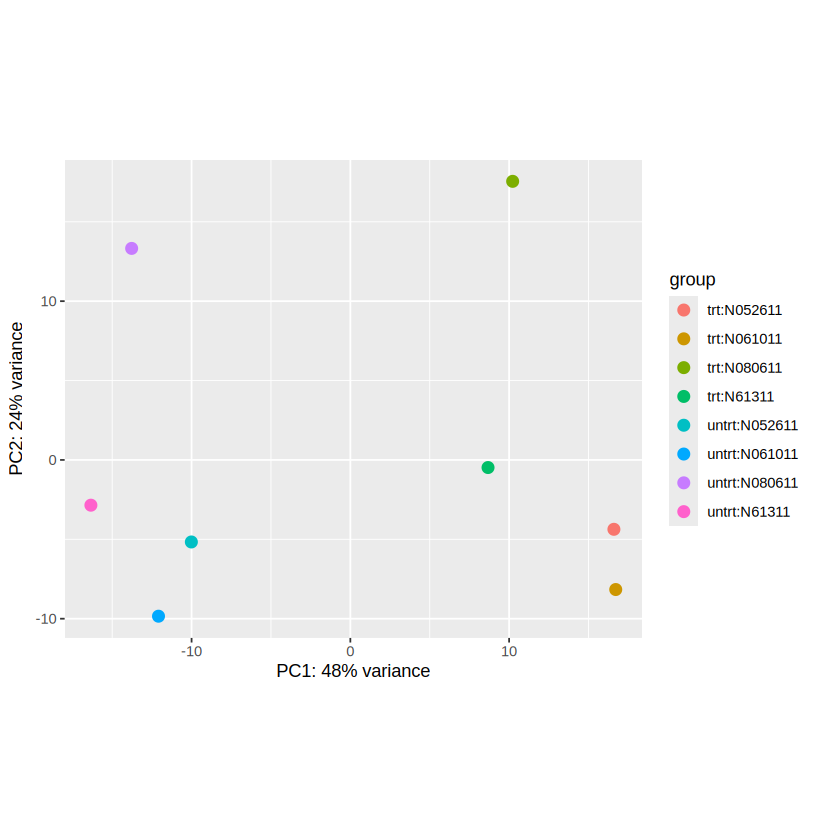

In [3]:
vsd <- vst(dds, blind = FALSE)
pca <- plotPCA(vsd, intgroup = c("dex", "cell"))
ggsave("pca.png", pca, width = 6, height = 5, dpi = 300)
print(pca)

## 4. Results table

In [4]:
res <- results(dds, contrast = c("dex", "trt", "untrt"), alpha = 0.05)
summary(res)

res_df <- as.data.frame(res)
res_df$ensembl <- rownames(res_df)
res_df$symbol <- mapIds(org.Hs.eg.db, keys = res_df$ensembl,
                        column = "SYMBOL", keytype = "ENSEMBL", multiVals = "first")
res_df <- res_df %>% arrange(padj)
write.csv(res_df, "deseq2_results_all.csv", row.names = FALSE)
head(res_df, 15)


out of 16139 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2190, 14%
LFC < 0 (down)     : 1891, 12%
outliers [1]       : 0, 0%
low counts [2]     : 313, 1.9%
(mean count < 10)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



'select()' returned 1:many mapping between keys and columns



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl,symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000152583,997.9612,4.570944,0.18424377,24.80922,7.129668e-136,5.641706e-132,ENSG00000152583,SPARCL1
ENSG00000165995,495.5675,3.287083,0.13245226,24.81711,5.859407e-136,5.641706e-132,ENSG00000165995,CACNB2
ENSG00000120129,3411.9661,2.943859,0.12214454,24.10144,2.414560e-128,1.273761e-124,ENSG00000120129,DUSP1
ENSG00000101347,12712.9456,3.763021,0.15643773,24.05444,7.501584e-128,2.968002e-124,ENSG00000101347,SAMHD1
ENSG00000189221,2343.5733,3.349721,0.14221411,23.55407,1.140346e-122,3.609424e-119,ENSG00000189221,MAOA
ENSG00000211445,12298.1966,3.726415,0.16721861,22.28469,5.201707e-110,1.372037e-106,ENSG00000211445,GPX3
ENSG00000157214,3012.8580,1.972783,0.09088482,21.70641,1.784727e-104,4.035014e-101,ENSG00000157214,STEAP2
ENSG00000162614,5399.1360,2.031697,0.09574481,21.21991,6.253729e-100,1.237144e-96,ENSG00000162614,NEXN
ENSG00000125148,3659.6960,2.207006,0.10691516,20.64259,1.137912e-94,2.000955e-91,ENSG00000125148,MT2A


## 5. Volcano plot

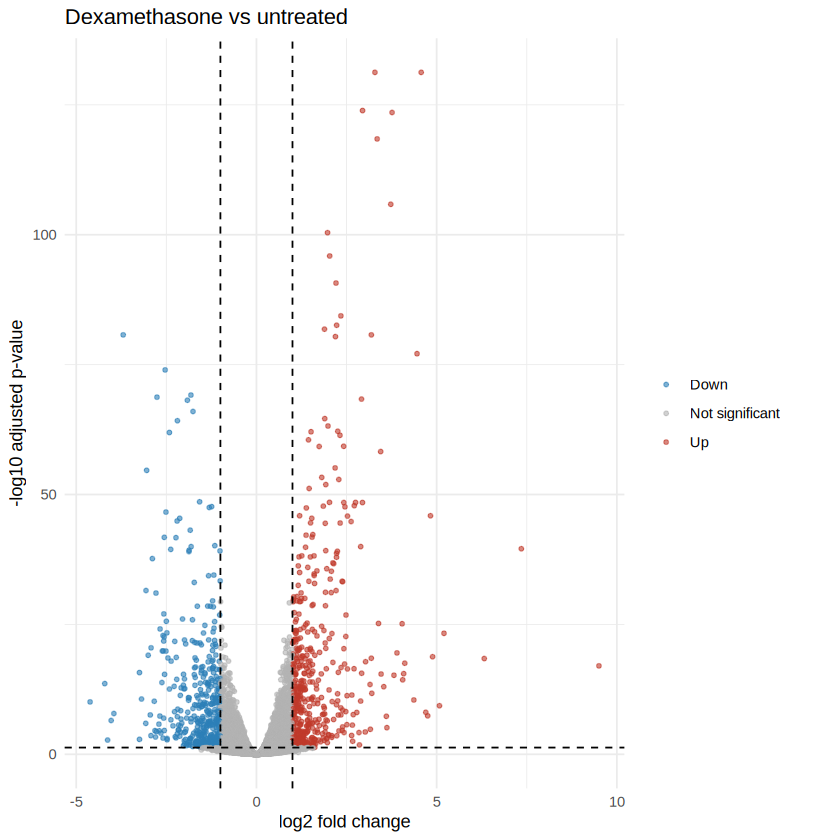

In [5]:
plot_df <- res_df %>%
  filter(!is.na(padj)) %>%
  mutate(group = case_when(padj < 0.05 & log2FoldChange >  1 ~ "Up",
                           padj < 0.05 & log2FoldChange < -1 ~ "Down",
                           TRUE ~ "Not significant"))
volcano <- ggplot(plot_df, aes(log2FoldChange, -log10(padj), colour = group)) +
  geom_point(alpha = 0.6, size = 1) +
  scale_colour_manual(values = c(Down = "#2c7fb8", "Not significant" = "grey70", Up = "#c0392b")) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
  labs(title = "Dexamethasone vs untreated", x = "log2 fold change",
       y = "-log10 adjusted p-value", colour = NULL) +
  theme_minimal()
ggsave("volcano.png", volcano, width = 7, height = 5, dpi = 300)
print(volcano)

## 6. Heatmap of the top 30 genes

In [8]:
top <- head(plot_df$ensembl, 30)
mat <- assay(vsd)[top, ]
mat <- mat - rowMeans(mat)
lab <- plot_df$symbol[match(top, plot_df$ensembl)]
rownames(mat) <- ifelse(is.na(lab), top, lab)
anno <- as.data.frame(colData(vsd)[, c("dex", "cell")])
pheatmap(mat, annotation_col = anno, filename = "heatmap_top30.png", width = 7, height = 8)
pheatmap(mat, annotation_col = anno)

## 7. Save everything

In [9]:
writeLines(capture.output(sessionInfo()), "sessionInfo.txt")
system("zip -q results.zip pca.png volcano.png heatmap_top30.png deseq2_results_all.csv sessionInfo.txt")
list.files()
# Download: open the Files panel (folder icon on the left), right-click results.zip, choose Download.

[1] "deseq2_results_all.csv" "heatmap_top30.png"      "pca.png"               
[4] "results.zip"            "sample_data"            "sessionInfo.txt"       
[7] "volcano.png"